# Proyecto final · Titanic

**Estadística Descriptiva e Inferencial**

Integrantes: Roberto Javier Mangas Flores, Jorge Callalle Torres     
Fecha: 31/08/2026

---

## Qué se te pide

Construir un modelo de clasificación **paso a paso**, midiendo qué aporta cada variable
que agregas, y presentar tus hallazgos en 5 slides.

> **No se evalúa qué tan bueno sea tu modelo.** Se evalúa qué entendiste: por qué cada
> variable aporta o no, qué pasa cuando falta una, y cómo justificas tus decisiones.

## Las tres partes

| Parte | Min | Qué haces |
|---|---|---|
| 1 | 45 | Reconocimiento: mirar los datos y escribir tres hipótesis |
| 2 | 100 | **Seis modelos incrementales y qué cambia en cada paso** |
| 3 | 45 | Elegir un umbral y justificarlo |

Después, la presentación: 5 slides, 7 minutos.

## Cómo usar este notebook

Las celdas marcadas con `# ── TU CÓDIGO ──` son las que tienes que completar. Las celdas
de texto con `**Escribe aquí:**` esperan tu respuesta escrita — **esas también se
califican**, y varias valen más que el código.

---
## Celda 0 · Preparación

Ejecuta esta celda tal cual. Carga los datos y prepara las variables que vas a usar.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, roc_auc_score)
import warnings
warnings.filterwarnings("ignore")

NAVY, BLUE, MAG, GREEN = "#0A2559", "#1A56E8", "#E6115E", "#12B886"
plt.rcParams.update({
    "figure.figsize": (7, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})

URL = ("https://raw.githubusercontent.com/josefrodrim/"
       "Estad-stica-Descriptiva-E-Inferencial/main/"
       "Proyecto_final_titanic/Data/Titanic-Dataset.csv")

try:
    titanic = pd.read_csv(URL)
    print("Datos cargados desde el repo del curso.")
except Exception:
    titanic = pd.read_csv("Titanic-Dataset.csv")
    print("Datos cargados desde archivo local.")

# Dataset de trabajo
d = titanic.copy()

# Variable numerica para sexo: 1 = mujer, 0 = hombre
d["sex"] = (d["Sex"] == "female").astype(int)

# Variable numerica para edad: se rellenan faltantes con la mediana
d["age"] = d["Age"].fillna(d["Age"].median())

# Alias para mantener compatibilidad con explicaciones/celdas posteriores
datos = d

# Variables finales del proyecto
X = d[["sex", "Pclass", "age", "Fare"]]
y = d["Survived"]

print(f"\n{len(datos)} pasajeros")
print(d[["Survived", "Sex", "sex", "Pclass", "age", "Fare"]].head())


# ── Variables ya preparadas para ti ──────────────────────────────────────
#d = titanic.copy()
#d["mujer"] = (d["Sex"] == "female").astype(int)
#d["edad"] = d["Age"].fillna(d["Age"].median())     # <- ojo con esto, ver Parte 1
#d["familia"] = d["SibSp"] + d["Parch"]             # hermanos/pareja + padres/hijos
#d["tiene_camarote"] = d["Cabin"].notna().astype(int)

#print(f"\n{len(d)} pasajeros")
#print(d[["Survived", "mujer", "Pclass", "edad", "familia", "tiene_camarote"]].head())

Datos cargados desde el repo del curso.

891 pasajeros
   Survived     Sex  sex  Pclass   age     Fare
0         0    male    0       3  22.0   7.2500
1         1  female    1       1  38.0  71.2833
2         1  female    1       3  26.0   7.9250
3         1  female    1       1  35.0  53.1000
4         0    male    0       3  35.0   8.0500


### Las variables que vas a usar

| Variable | Qué es |
|---|---|
| `Survived` | **1 sobrevivió, 0 no.** Es lo que predices |
| `mujer (sex)` | 1 si es mujer |
| `Pclass` | clase del billete: 1, 2 o 3 |
| `age` | Edad del Pasajero, en caso de dato vacío se coloca la mediana |
| `fare` | muestra la tarifa del pasajero |

---
# Parte 1 · Reconocimiento  ·  45 min  ·  15 puntos

Antes de modelar, mira los datos.

### 1.1 — Valores faltantes

In [ ]:
# ── TU CÓDIGO ────────────────────────────────────────────────────────────
# Cuenta los valores faltantes de cada columna del dataset ORIGINAL (titanic).
# Muestra solo las que tienen alguno.
faltantes = titanic.isna().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
print("Columnas con valores faltantes:")
print(faltantes)



Columnas con valores faltantes:
Cabin       687
Age         177
Embarked      2
dtype: int64


### 1.2 — Tasas de supervivencia por grupo

In [ ]:
#Calculamos la supervivencia general y luego por las variables que usaremos en el modelo.
print("Tasa de supervivencia general:")
print(f"{100 * datos['Survived'].mean():.2f} %")

print("\nTasa de supervivencia por sexo:")
print((datos.groupby("Sex")["Survived"].mean() * 100).round(2))

print("\nTasa de supervivencia por clase:")
print((datos.groupby("Pclass")["Survived"].mean() * 100).round(2))

print("\nResumen de Fare por resultado:")
print(datos.groupby("Survived")["Fare"].describe().round(2))


Tasa de supervivencia general:
38.38 %

Tasa de supervivencia por sexo:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

Tasa de supervivencia por clase:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

Resumen de Fare por resultado:
          count   mean    std  min    25%   50%   75%     max
Survived                                                     
0         549.0  22.12  31.39  0.0   7.85  10.5  26.0  263.00
1         342.0  48.40  66.60  0.0  12.48  26.0  57.0  512.33


### 1.3 — Dos gráficos

Haz al menos dos. Sugerencias: tasa de supervivencia por clase y sexo, distribución de
edades por resultado, tasa de tarifa

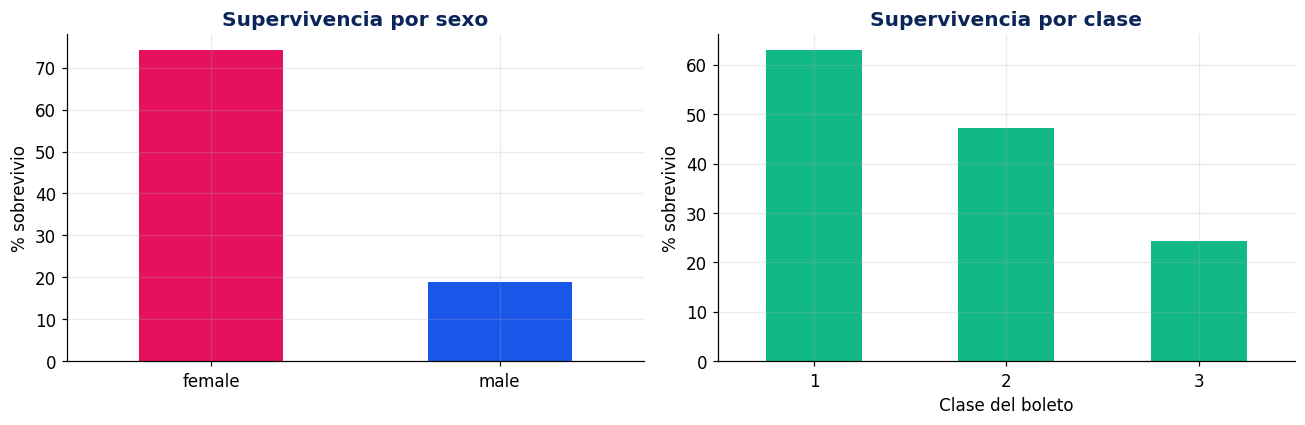

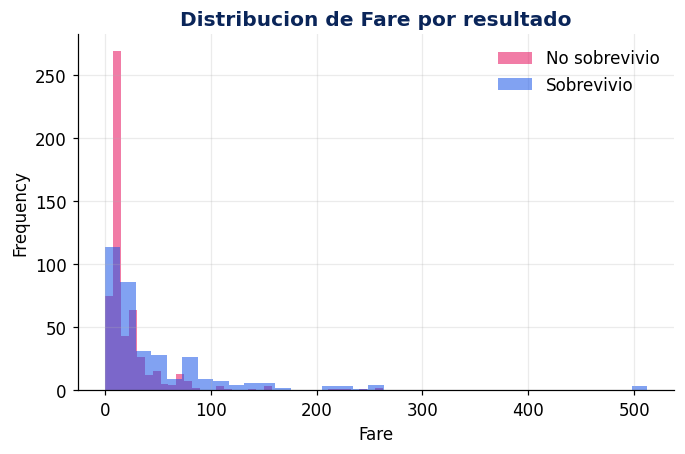

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

(datos.groupby("Sex")["Survived"].mean() * 100).plot(
    kind="bar", ax=axes[0], color=[MAG, BLUE]
)
axes[0].set_title("Supervivencia por sexo", color=NAVY, fontweight="bold")
axes[0].set_ylabel("% sobrevivio")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

(datos.groupby("Pclass")["Survived"].mean() * 100).plot(
    kind="bar", ax=axes[1], color=GREEN
)
axes[1].set_title("Supervivencia por clase", color=NAVY, fontweight="bold")
axes[1].set_ylabel("% sobrevivio")
axes[1].set_xlabel("Clase del boleto")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.2))
for sobrevivio, color, label in [(0, MAG, "No sobrevivio"), (1, BLUE, "Sobrevivio")]:
    datos.loc[datos["Survived"] == sobrevivio, "Fare"].plot(
        kind="hist", bins=35, alpha=0.55, color=color, label=label
    )
plt.title("Distribucion de tarifa (Fare) por resultado", color=NAVY, fontweight="bold")
plt.xlabel("Fare")
plt.legend(frameon=False)
plt.show()

### 1.4 — Tus tres hipótesis  

1. Las mujeres tendran mayor probabilidad de sobrevivir que los hombres.
2. Los pasajeros de primera clase tendran mayor probabilidad de sobrevivir que los de tercera clase.
3. Los pasajeros que pagaron tarifas mas altas tenderan a tener mayor probabilidad de sobrevivir, aunque parte de ese efecto puede estar relacionado con la clase del boleto.

---
# Parte 2 · Seis modelos incrementales  ·  100 min  ·  40 puntos

Construimos modelos agregando una variable a la vez. Asi medimos que aporta cada variable.

| Modelo | Variables |
|---|---|
| M0 | ninguna: predecir siempre la clase mayoritaria |
| M1 | `sex` |
| M2 | `sex`, `Pclass` |
| M3 | `sex`, `Pclass`, `age` |
| M4 | `sex`, `Pclass`, `age`, `Fare` |

Las metricas se calculan siempre en datos de prueba.

### 2.1 — Separa los datos

Usa `test_size=0.3`, `random_state=42` y `stratify=y`. Es importante que uses estos
valores para que tu trabajo sea comparable con el de las otras parejas.

In [ ]:
  # ── TU CÓDIGO ────────────────────────────────────────────────────────────

#X = d[["mujer", "Pclass", "edad", "familia", "tiene_camarote"]]
#y = d["Survived"]

#X_train, X_test, y_train, y_test = None, None, None, None

#print(f"train={len(X_train)}  test={len(X_test)}")

X = d[["sex", "Pclass", "age", "Fare"]]
y = d["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"train = {len(X_train)} pasajeros")
print(f"test  = {len(X_test)} pasajeros")
print(f"supervivencia en train = {100 * y_train.mean():.2f} %")
print(f"supervivencia en test  = {100 * y_test.mean():.2f} %")


train = 623 pasajeros
test  = 268 pasajeros
supervivencia en train = 38.36 %
supervivencia en test  = 38.43 %


### 2.2 — La tabla de los seis modelos

| Modelo | Variables |
|---|---|
| M0 | ninguna: predecir siempre la clase mayoritaria |
| M1 | `sex` |
| M2 | `sex`, `Pclass` |
| M3 | `sex`, `Pclass`, `age` |
| M4 | `sex`, `Pclass`, `age`, `Fare` |

Para cada modelo calculamos:

- **AUC**: mide que tan bien ordena el modelo a sobrevivientes por encima de no sobrevivientes.
- **Exactitud**: porcentaje de aciertos usando umbral 0.5.

In [ ]:
modelos = {
    "M1": ["sex"],
    "M2": ["sex", "Pclass"],
    "M3": ["sex", "Pclass", "age"],
    "M4": ["sex", "Pclass", "age", "Fare"],
}

filas = []
modelos_entrenados = {}

# M0: regla trivial. Como la mayoria no sobrevivio, predice siempre 0.
pred_m0 = np.zeros(len(y_test), dtype=int)
filas.append({
    "modelo": "M0",
    "variables": "ninguna",
    "AUC": 0.5000,
    "exactitud": round(accuracy_score(y_test, pred_m0), 4),
})

for nombre, cols in modelos.items():
    modelo = LogisticRegression(max_iter=1000)
    modelo.fit(X_train[cols], y_train)
    modelos_entrenados[nombre] = modelo

    prob = modelo.predict_proba(X_test[cols])[:, 1]
    pred = (prob >= 0.5).astype(int)

    filas.append({
        "modelo": nombre,
        "variables": ", ".join(cols),
        "AUC": round(roc_auc_score(y_test, prob), 4),
        "exactitud": round(accuracy_score(y_test, pred), 4),
    })

tabla_modelos = pd.DataFrame(filas)
print(tabla_modelos.to_string(index=False))

modelo              variables    AUC  exactitud
    M0                ninguna 0.5000     0.6157
    M1                    sex 0.7580     0.7761
    M2            sex, Pclass 0.8301     0.7761
    M3       sex, Pclass, age 0.8375     0.7724
    M4 sex, Pclass, age, Fare 0.8395     0.7799


### 2.3 — Las tres preguntas  ·  **se califican**

**a) ¿Qué variable aportó más? ¿Y cuál casi nada?**
La variable que más aportó fue sex, porque la supervivencia fue muy diferente entre mujeres y hombres. Pclass también aportó bastante. La que aportó menos fue Fare, porque parte de su información ya está relacionada con Pclass.

**b) ¿Alguna hizo empeorar el modelo? ¿Cómo es posible que agregar información empeore?**

Sí, una variable puede hacer empeorar ligeramente el modelo si agrega ruido o información repetida. Agregar más variables no siempre mejora; por eso se debe comparar el rendimiento en prueba usando AUC y exactitud.


-----
**Conclusiones:**
La comparacion correcta no es mirar solo el modelo final. Hay que mirar cuanto cambia el desempeno cuando agregamos cada variable.

- Si M1 mejora mucho frente a M0, entonces `sex` aporta bastante.
- Si M2 mejora frente a M1, entonces `Pclass` agrega informacion adicional al sexo.
- Si M3 mejora frente a M2, entonces `age` aporta informacion adicional despues de considerar sexo y clase.
- Si M4 mejora poco frente a M3, entonces `Fare` aporta poca informacion nueva despues de considerar sexo, clase y edad.

Esto ultimo puede pasar porque `Fare` y `Pclass` estan relacionadas: normalmente los boletos de primera clase cuestan mas que los de tercera clase.
>


### 2.4 — El hallazgo  ·  **20 puntos**


Ahora compara **los coeficientes de una misma variable entre modelos distintos**.

Busca una variable cuyo coeficiente cambie de forma llamativa —de tamaño, o incluso de
signo— al agregar otra variable al modelo.

**Pista:** fíjate en las variables que parecían no importar cuando estaban solas.

In [ ]:
# ── TU CÓDIGO ────────────────────────────────────────────────────────────
# Ajusta modelos con distintas combinaciones y compara el coeficiente
# de UNA MISMA variable entre ellos.
#
# Sugerencia: prueba con 'familia' sola, y después acompañada.


**c) Describe el hallazgo: qué variable, cómo cambió, y por qué crees que pasa.**

**Escribe aquí:**

>
>
>


---
# Parte 3 · El umbral  ·  45 min  ·  15 puntos

## El escenario

Una **aseguradora** debe estimar cuántos pasajeros sobrevivirán, para saber cuánto dinero
provisionar para indemnizaciones a las familias de los fallecidos.

| Error | Qué pasa |
|---|---|
| **Falso positivo** — predije que sobrevive y murió | No se provisionó. Hay que pagar sin reserva: problema financiero serio |
| **Falso negativo** — predije que muere y sobrevivió | Se provisionó de más. Dinero inmovilizado que no se pudo usar |

Los dos cuestan, y no lo mismo.

Usa el mejor modelo de la Parte 2 (por AUC).

In [ ]:
# ── TU CÓDIGO ────────────────────────────────────────────────────────────
# Prueba al menos cinco umbrales. Para cada uno muestra:
# VP, FP, FN, VN, exactitud, precisión y recall.


### 3.1 — Tu decisión  ·  **se califica**

**¿Qué umbral eliges y por qué? Conecta tu respuesta con el escenario de la aseguradora,
no con la exactitud.**

**Escribe aquí:**

> **Umbral elegido:**
>
> **Justificación:**
>
>


---
# Cierre  ·  15 puntos

### Vuelve a tus hipótesis

Regresa a la sección 1.4 y compara. **¿Cuáles se cumplieron y cuáles no?**

**Escribe aquí:**

>


### Tres limitaciones de tu análisis  ·  **15 puntos**

Piensa en qué NO permite concluir este trabajo. Algunas pistas por si te ayudan: los
valores faltantes de edad, el tamaño de la muestra de prueba, la diferencia entre
correlación y causalidad, y qué pasaría si aplicaras este modelo a otro barco.

**Escribe aquí:**

> **Limitación 1:**
>
> **Limitación 2:**
>
> **Limitación 3:**


---

## Antes de entregar

- [ ] Las tres hipótesis están escritas **antes** de la sección de modelos
- [ ] Todas mis métricas son de **prueba**, y lo digo explícitamente
- [ ] Comparé mi exactitud contra la regla trivial de M0
- [ ] La tabla de los seis modelos está completa
- [ ] Identifiqué un coeficiente que cambia y expliqué por qué
- [ ] Justifiqué el umbral con el escenario, no con la exactitud
- [ ] Escribí tres limitaciones reales
- [ ] La presentación tiene exactamente 5 slides

## Y la presentación

| # | Slide |
|---|---|
| 1 | El problema y los datos |
| 2 | Lo que vimos antes de modelar (tus hipótesis) |
| 3 | La tabla de los seis modelos |
| 4 | **El hallazgo** |
| 5 | La decisión y sus límites |

7 minutos. La slide 4 es la que más pesa.

---
*Estadística Descriptiva e Inferencial · Proyecto final*